# Founder Departure Survival Corpus

This notebook demonstrates the assembly script (`data.py`) from the **Founder Departure Survival Corpus** dataset artifact.

The full pipeline mines public GitHub repositories for founder-only **Truck-Factor-Developer-Detachment (TFDD)** events — the moment a project's sole "truck factor" developer (the person whose departure would leave the project unable to continue, per the Degree-of-Authorship/Truck-Factor methodology of Avelino et al. ICPC'16 / ESEM'19) goes silent. For each mined repository it computes:

- **DOA** (Degree of Authorship) per file per author: `DOA = 3.293 + 1.098*FirstAuthor + 0.164*Deliveries - 0.321*ln(1+Acceptances)`
- **Truck Factor (TF)**: greedy removal of the highest-file-count DOA-primary author while remaining authors still cover ≥50% of files, recomputed yearly to locate the first TFDD event
- Pre-TFDD covariates (6-12 month authority-diffusion window) and TFDD-snapshot covariates (stars, forks, contributors, language, etc.)
- A binary survival label: whether the project was still active after the founder's departure (`Active_survived`) or not (`Inactive_did_not_survive`)

This demo notebook takes the **already-mined per-repo results** (the `temp/repo_results/*.json` files the full pipeline produces after cloning and walking each repo's commit history) and runs the exact same `data.py` assembly logic — filtering to qualifying repos, extracting predictor covariates, and building the final `input`/`output` schema — on a small curated subset. It ends with a summary table and a plot of the predictor/label relationship.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is not pre-installed on Colab
_pip('loguru')

# matplotlib is pre-installed on Colab; install locally at Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Original imports from data.py, plus matplotlib for the results plot at the end
import json
import sys
from pathlib import Path

from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the mined repo results

`mini_demo_data.json` is a curated subset of the raw per-repo mining output — the same shape as the `temp/repo_results/*.json` files that `data.py` normally globs from disk. It's a mix of 20 **qualified** repos (10 that survived their founder's departure, 10 that didn't) plus one example of each **discard reason** the mining funnel applies, so the filtering step below has something to filter.

The loader tries the GitHub raw URL first (works once this artifact is published) and falls back to the local file (works right now, and in this notebook's own working directory on Colab after uploading the file).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-24ffbe-pre-departure-bus-factor-diffusion/main/round-2/dataset-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data)} raw repo mining results")

Loaded 27 raw repo mining results


## Config

The original `data.py` has no tunable numeric parameters — it's a deterministic assembly/filtering step, not a model with iterations or sample sizes. The one "parameter" is which/how-many raw repo results to process; here that's simply all of `data` (the small curated subset loaded above). No other config is needed to reproduce the full logic end-to-end.

In [5]:
# Config — process every record in the loaded (curated) mini dataset.
# In the full pipeline this would instead be every file matched by
# RESULTS_GLOB = "temp/repo_results/*.json" (all 522 mined candidates).
raw_results = data

## Build one dataset example per qualifying repo

`build_example` is copied unchanged from `data.py`. For a qualifying repo it pulls the pre-TFDD authority-diffusion window (`pre`) and the TFDD-snapshot covariates (`cov`) out of the raw mining result, packs the predictors into `input` (a JSON string, matching the corpus's on-disk format), and carries every other field through as `metadata_*` so downstream analysis can recompute alternate windows without re-mining.

In [6]:
def build_example(r: dict) -> dict:
    pre = r["pre_tfdd_window"]
    cov = r["tfdd_snapshot_covariates"]
    input_features = {
        "founder_commit_share_pre_tfdd": pre["founder_commit_share"],
        "n_distinct_new_primary_owners_pre_tfdd": pre["n_distinct_new_primary_owners"],
        "founder_early_authorship_share": r["founder_early_authorship_share"],
        "stars": cov["stars"],
        "forks": cov["forks"],
        "total_contributors": cov["total_contributors"],
        "language": cov["language"],
        "license": cov["license"],
        "project_age_days": cov["project_age_days"],
        "n_commits_total": r["n_commits"],
        "n_files_total": r["n_files"],
        "history_span_years": r["history_span_years"],
    }
    example = {
        "input": json.dumps(input_features, sort_keys=True),
        "output": r["survival_label"],
        "metadata_full_name": r["full_name"],
        "metadata_activity_bucket": r["activity_bucket"],
        "metadata_founder": r["founder"],
        "metadata_tfdd": r["tfdd"],
        "metadata_pre_tfdd_window": pre,
        "metadata_tfdd_snapshot_covariates": cov,
        "metadata_yearly_doa_tf_tables": r["yearly_tables"],
        "metadata_post_tfdd_monthly_commits": r["post_tfdd_monthly_commits"],
        "metadata_post_tfdd_months_available": r["post_tfdd_months_available"],
        "metadata_years_after_tfdd": r["years_after_tfdd"],
        "metadata_repo_meta": r["meta"],
        "metadata_repo_first_commit": r["repo_first_commit"],
        "metadata_repo_last_commit": r["repo_last_commit"],
        "metadata_task_type": "binary_classification",
        "metadata_n_classes": 2,
    }
    return example

## Filter to qualifying repos and assemble the corpus

This mirrors `data.py`'s `main()`. The only change from the original is the source of the raw results: instead of `glob.glob(RESULTS_GLOB)` reading `temp/repo_results/*.json` off disk, we iterate the `raw_results` list already loaded into memory (each element is exactly one of those per-repo JSON files' contents). Everything else — the qualified/discarded split, the discard-reason tally, and the final `output` dict with its `metadata` block — is unchanged.

In [7]:
logger.info(f"Found {len(raw_results)} mined repo result records")
qualified = []
discard_reasons = {}
for r in raw_results:
    if r.get("status") == "qualified":
        qualified.append(r)
    else:
        reason = r.get("discard_reason", "unknown")
        discard_reasons[reason] = discard_reasons.get(reason, 0) + 1
logger.info(f"Qualified repos: {len(qualified)}")
logger.info(f"Discard reasons: {json.dumps(discard_reasons, indent=2)}")

examples = [build_example(r) for r in qualified]
output = {
    "metadata": {
        "source": "GitHub REST search API (candidate discovery) + git log (--filter=blob:none) "
                   "for full commit history mining",
        "description": "Single-founder GitHub repos with founder-only Truck-Factor-Developer-"
                        "Detachment (TFDD) events, per Avelino et al. ICPC'16 (DOA/TF algorithm) "
                        "and Avelino et al. ESEM'19 (TFDD/survival definitions). Each example is "
                        "one qualifying repo; input=pre-TFDD/snapshot covariates, output=survival "
                        "label (Active_survived / Inactive_did_not_survive).",
        "n_qualified": len(qualified),
        "discard_reason_counts": discard_reasons,
        "doa_formula": "DOA(d,f) = 3.293 + 1.098*FirstAuthor(d,f) + 0.164*Deliveries(d,f) "
                       "- 0.321*ln(1+Acceptances(d,f))",
        "tf_algorithm": "greedy removal of highest-file-count DOA-primary-author while "
                        "remaining-authors' file coverage >= 0.5",
    },
    "datasets": [
        {"dataset": "founder_departure_tfdd_corpus", "examples": examples}
    ],
}
logger.info(f"Assembled {len(examples)} examples into the demo corpus")

19:58:36|INFO   |Found 27 mined repo result records


19:58:36|INFO   |Qualified repos: 20


19:58:36|INFO   |Discard reasons: {
  "non_software_repo_low_code_fraction": 1,
  "too_few_commits": 1,
  "right_censored_insufficient_post_tfdd_history": 1,
  "no_qualifying_founder_only_tfdd": 1,
  "mining_artifact_migration_squash": 1,
  "too_large_history": 1,
  "single_developer_only": 1
}


19:58:36|INFO   |Assembled 20 examples into the demo corpus


## Results

A summary table of the assembled examples, followed by a plot of the two headline pre-TFDD covariates split by survival label — the question this dataset was built to let downstream experiments answer: does authority diffusion *before* the founder leaves predict whether the project survives?

repo                                     label                         founder_share_pre  new_owners_pre
---------------------------------------------------------------------------------------------------------
mholt/PapaParse                          Active_survived                           0.000               6
kaelzhang/node-ignore                    Active_survived                           0.000               2
hapijs/boom                              Active_survived                           0.000               2
qbittorrent/qBittorrent                  Active_survived                           0.000              14
ruby-grape/grape                         Active_survived                           0.000              18
flightphp/core                           Active_survived                                                                                                                                                                                                  N/A           

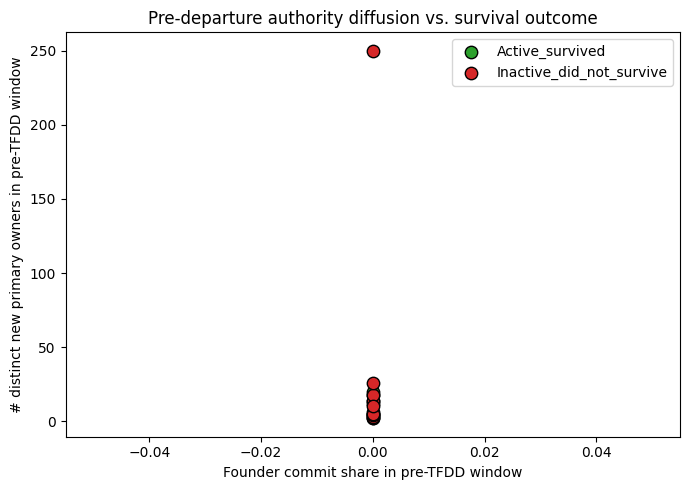

In [8]:
def _fmt(v, spec):
    return format(v, spec) if v is not None else "N/A".rjust(int("".join(c for c in spec if c.isdigit()) or "0"))

print(f"{'repo':40s} {'label':28s} {'founder_share_pre':>18s} {'new_owners_pre':>15s}")
print("-" * 105)
for ex in examples:
    feats = json.loads(ex["input"])
    print(
        f"{ex['metadata_full_name']:40s} {ex['output']:28s} "
        f"{_fmt(feats['founder_commit_share_pre_tfdd'], '18.3f')} "
        f"{_fmt(feats['n_distinct_new_primary_owners_pre_tfdd'], '15d')}"
    )

print(f"\nDiscard reasons seen in this demo subset: {json.dumps(discard_reasons, indent=2)}")

# Plot: pre-TFDD founder commit share vs. number of new primary owners, colored by survival
# (skip any example with a missing covariate — pre-TFDD windows can be null for some repos)
active_x, active_y = [], []
inactive_x, inactive_y = [], []
for ex in examples:
    feats = json.loads(ex["input"])
    x, y = feats["founder_commit_share_pre_tfdd"], feats["n_distinct_new_primary_owners_pre_tfdd"]
    if x is None or y is None:
        continue
    if ex["output"] == "Active_survived":
        active_x.append(x)
        active_y.append(y)
    else:
        inactive_x.append(x)
        inactive_y.append(y)

plt.figure(figsize=(7, 5))
plt.scatter(active_x, active_y, label="Active_survived", color="tab:green", s=80, edgecolor="black")
plt.scatter(inactive_x, inactive_y, label="Inactive_did_not_survive", color="tab:red", s=80, edgecolor="black")
plt.xlabel("Founder commit share in pre-TFDD window")
plt.ylabel("# distinct new primary owners in pre-TFDD window")
plt.title("Pre-departure authority diffusion vs. survival outcome")
plt.legend()
plt.tight_layout()
plt.show()